# 09. Origin-Destination Flow Analysis

## Objective

Analyze the major origin-destination (OD) travel flows between taxi zones
using the aggregated OD statistics generated during the taxi-zone processing
stage.

The analysis identifies the most frequently travelled zone pairs and
high-volume travel corridors, providing insight into how demand moves
between major locations.

### Key questions

1. Which origin-destination pairs have the highest trip volumes?
2. Which zones act as major origins and destinations?
3. Which travel corridors are most important for taxi operations?

In [2]:
# Load the pre-aggregated origin-destination flow statistics.
# Using the processed file avoids reprocessing the full raw taxi dataset.

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\arudk\Downloads\UrbanFlow_AI")

ZONE_OUTPUT_DIR = (
    BASE_DIR
    / "data"
    / "processed"
    / "taxi_zone"
)

FIGURE_DIR = (
    BASE_DIR
    / "reports"
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

od_flows = pd.read_csv(
    ZONE_OUTPUT_DIR / "od_flow_statistics.csv"
)

print("OD flow dataset shape:", od_flows.shape)
print("\nColumns:")
print(od_flows.columns.tolist())

print("\nFirst records:")
display(od_flows.head())

OD flow dataset shape: (55933, 5)

Columns:
['origin_loc_id', 'dest_loc_id', 'trip_count', 'origin_zone', 'destination_zone']

First records:


,origin_loc_id,dest_loc_id,trip_count,origin_zone,destination_zone
0,1,1,6004,Newark Airport,Newark Airport
1,1,125,4,Newark Airport,Hudson Sq
2,1,265,215,Newark Airport,Outside of NYC
3,2,28,1,Jamaica Bay,Briarwood/Jamaica Hills
4,3,3,190,Allerton/Pelham Gardens,Allerton/Pelham Gardens


## 2. Major Origin-Destination Flows

Origin-destination flows are ranked by trip count to identify the most
frequently travelled zone pairs.

These high-volume OD pairs represent important travel corridors and can
help identify recurring movement patterns within the taxi network.

In [5]:
# Rank the most frequently travelled origin-destination pairs.

top_od_flows = (
    od_flows
    .sort_values("trip_count", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print("Top 20 origin-destination flows:")
display(top_od_flows)

Top 20 origin-destination flows:


,origin_loc_id,dest_loc_id,trip_count,origin_zone,destination_zone
0,237,236,301532,Upper East Side South,Upper East Side North
1,236,237,258572,Upper East Side North,Upper East Side South
2,237,237,214271,Upper East Side South,Upper East Side South
3,236,236,196494,Upper East Side North,Upper East Side North
4,161,237,140579,Midtown Center,Upper East Side South
5,237,161,132170,Upper East Side South,Midtown Center
6,161,236,112593,Midtown Center,Upper East Side North
7,132,132,105773,JFK Airport,JFK Airport
8,237,162,105640,Upper East Side South,Midtown East
9,142,239,104177,Lincoln Square East,Upper West Side South


### Interpreting OD flows

High-volume OD pairs reveal recurring travel corridors between taxi zones.
These flows complement the hotspot analysis by showing not only where trips
start, but also where passengers travel.

## 3. Top Origin-Destination Corridors

The visualization below shows the 15 highest-volume OD pairs across the
study period.

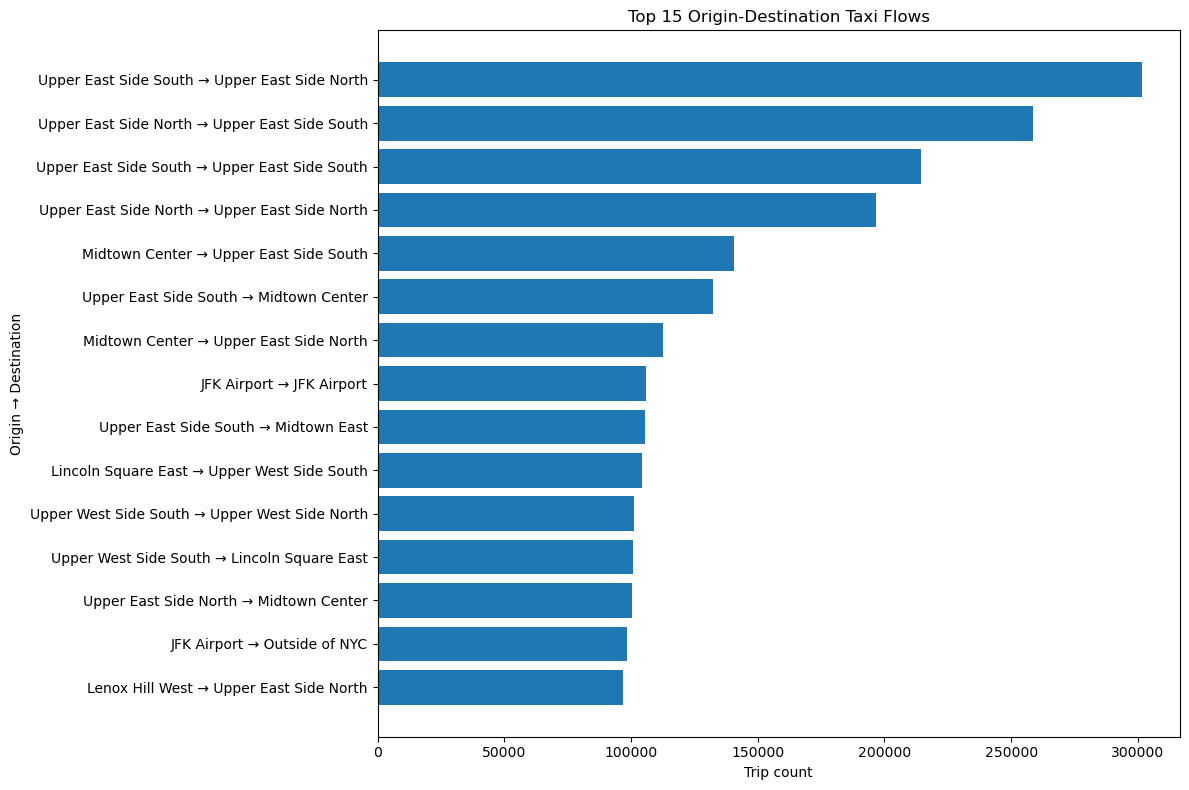

Figure saved: C:\Users\arudk\Downloads\UrbanFlow_AI\reports\figures\top_15_od_flows.png


In [9]:
# Create readable labels for the highest-volume OD corridors.

od_plot_data = (
    od_flows
    .sort_values("trip_count", ascending=False)
    .head(15)
    .copy()
)

od_plot_data["od_label"] = (
    od_plot_data["origin_zone"]
    + " → "
    + od_plot_data["destination_zone"]
)

od_plot_data = od_plot_data.sort_values(
    "trip_count",
    ascending=True
)

plt.figure(figsize=(12, 8))

plt.barh(
    od_plot_data["od_label"],
    od_plot_data["trip_count"]
)

plt.xlabel("Trip count")
plt.ylabel("Origin → Destination")
plt.title("Top 15 Origin-Destination Taxi Flows")

plt.tight_layout()

od_path = FIGURE_DIR / "top_15_od_flows.png"
plt.savefig(
    od_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved: {od_path}")

## 4. Major Origin and Destination Zones

In addition to individual OD pairs, total outgoing and incoming trip volumes
are aggregated by zone.

Total outgoing trips identify major origin zones, while total incoming trips
identify major destination zones. This provides a network-level view of the
most important taxi movement centres.

In [12]:
# Aggregate OD flows to identify the busiest origin and destination zones.

origin_summary = (
    od_flows
    .groupby(
        ["origin_loc_id", "origin_zone"],
        as_index=False
    )["trip_count"]
    .sum()
    .rename(
        columns={"trip_count": "outgoing_trip_count"}
    )
    .sort_values(
        "outgoing_trip_count",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

destination_summary = (
    od_flows
    .groupby(
        ["dest_loc_id", "destination_zone"],
        as_index=False
    )["trip_count"]
    .sum()
    .rename(
        columns={"trip_count": "incoming_trip_count"}
    )
    .sort_values(
        "incoming_trip_count",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

print("Top 15 origin zones by outgoing trips:")
display(origin_summary)

print("\nTop 15 destination zones by incoming trips:")
display(destination_summary)

Top 15 origin zones by outgoing trips:


,origin_loc_id,origin_zone,outgoing_trip_count
0,237,Upper East Side South,2113429
1,132,JFK Airport,2059989
2,161,Midtown Center,2023458
3,236,Upper East Side North,1867732
4,186,Penn Station/Madison Sq West,1508078
5,162,Midtown East,1477633
6,230,Times Sq/Theatre District,1450984
7,142,Lincoln Square East,1371620
8,170,Murray Hill,1273860
9,234,Union Sq,1268407



Top 15 destination zones by incoming trips:


,dest_loc_id,destination_zone,incoming_trip_count
0,236,Upper East Side North,1924538
1,237,Upper East Side South,1916867
2,161,Midtown Center,1686185
3,230,Times Sq/Theatre District,1399868
4,170,Murray Hill,1328707
5,162,Midtown East,1267101
6,68,East Chelsea,1227513
7,142,Lincoln Square East,1214145
8,239,Upper West Side South,1207346
9,141,Lenox Hill West,1155987


## 5. Major Origin and Destination Zones

The following comparison highlights the zones with the highest total outgoing
and incoming taxi volumes.

This helps distinguish zones that primarily generate taxi trips from those
that primarily receive them.

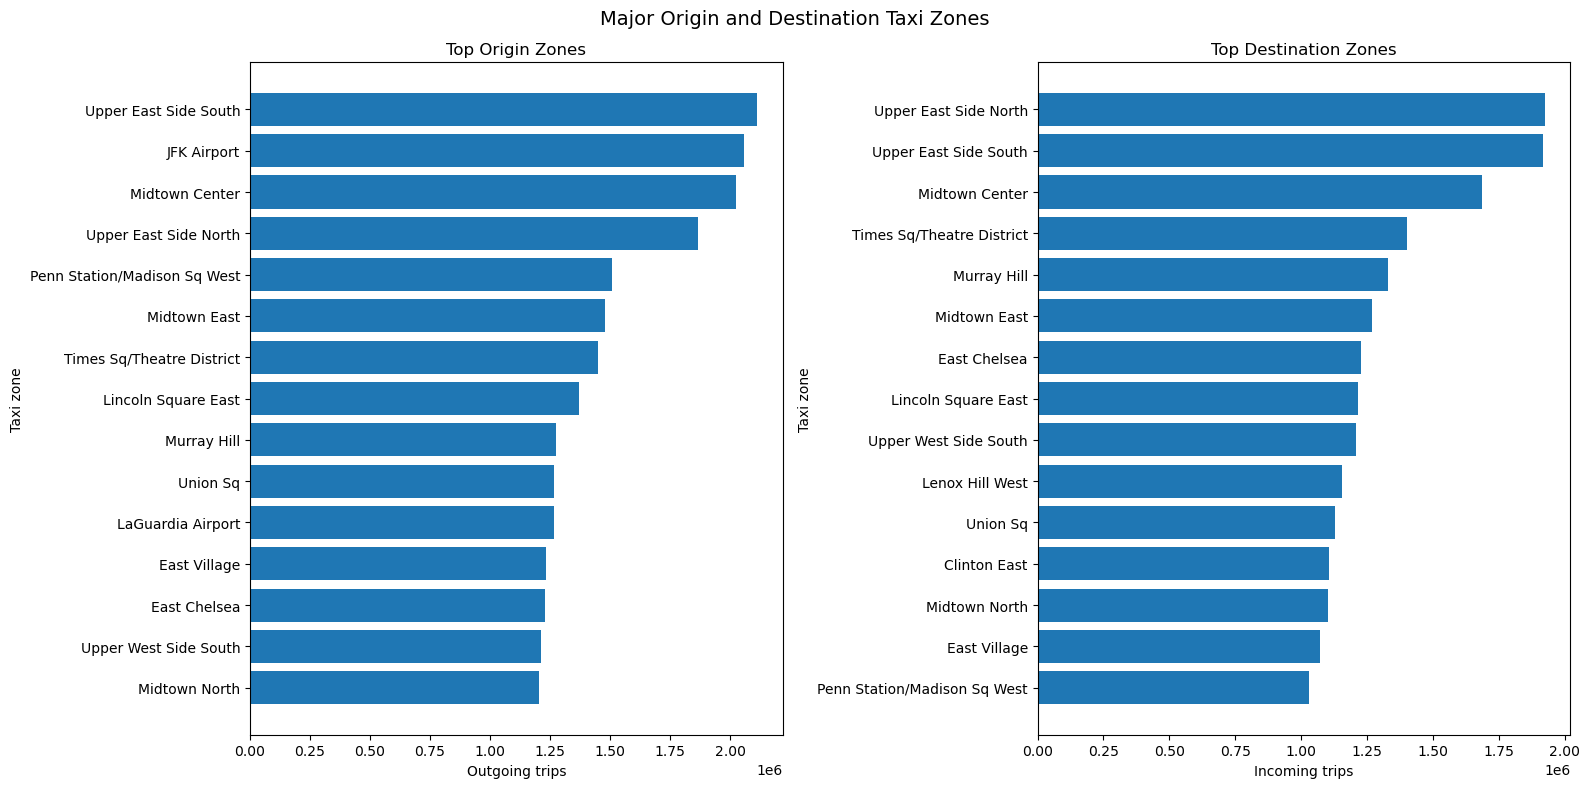

Figure saved: C:\Users\arudk\Downloads\UrbanFlow_AI\reports\figures\major_origin_destination_zones.png


In [15]:
# Compare outgoing and incoming trip volumes for the major zones.
# The two rankings are displayed separately to preserve their meaning.

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8)
)

# Major origins
origin_plot = origin_summary.sort_values(
    "outgoing_trip_count",
    ascending=True
)

axes[0].barh(
    origin_plot["origin_zone"],
    origin_plot["outgoing_trip_count"]
)

axes[0].set_title("Top Origin Zones")
axes[0].set_xlabel("Outgoing trips")
axes[0].set_ylabel("Taxi zone")

# Major destinations
destination_plot = destination_summary.sort_values(
    "incoming_trip_count",
    ascending=True
)

axes[1].barh(
    destination_plot["destination_zone"],
    destination_plot["incoming_trip_count"]
)

axes[1].set_title("Top Destination Zones")
axes[1].set_xlabel("Incoming trips")
axes[1].set_ylabel("Taxi zone")

plt.suptitle(
    "Major Origin and Destination Taxi Zones",
    fontsize=14
)

plt.tight_layout()

origin_destination_path = (
    FIGURE_DIR / "major_origin_destination_zones.png"
)

plt.savefig(
    origin_destination_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved: {origin_destination_path}")

## 6. Key OD Findings and Reporting Outputs

The OD analysis reveals that taxi movement is concentrated around a small
number of high-volume Manhattan corridors.

The strongest individual flow is between Upper East Side South and Upper
East Side North. Several other high-volume flows connect the Upper East Side
with Midtown, while airport-related flows form important directional
connections.

The distinction between major origins and destinations also shows that some
locations generate substantially more outgoing demand than incoming demand,
highlighting directional differences in the taxi network.

In [20]:
# Save the report-ready OD summaries.
# Paths are defined locally because each notebook should run independently.

from pathlib import Path

BASE_DIR = Path(r"C:\Users\arudk\Downloads\UrbanFlow_AI")

OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = BASE_DIR / "reports" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

top_od_output = OUTPUT_DIR / "top_20_od_flows.csv"
origin_output = OUTPUT_DIR / "top_origin_zones.csv"
destination_output = OUTPUT_DIR / "top_destination_zones.csv"

top_od_flows.to_csv(
    top_od_output,
    index=False
)

origin_summary.to_csv(
    origin_output,
    index=False
)

destination_summary.to_csv(
    destination_output,
    index=False
)

print("OD analysis outputs saved successfully:\n")

print(top_od_output)
print(origin_output)
print(destination_output)

print("\nKey OD finding:")

strongest_flow = top_od_flows.iloc[0]

print(
    f"{strongest_flow['origin_zone']} → "
    f"{strongest_flow['destination_zone']}: "
    f"{strongest_flow['trip_count']:,} trips"
)

OD analysis outputs saved successfully:

C:\Users\arudk\Downloads\UrbanFlow_AI\outputs\top_20_od_flows.csv
C:\Users\arudk\Downloads\UrbanFlow_AI\outputs\top_origin_zones.csv
C:\Users\arudk\Downloads\UrbanFlow_AI\outputs\top_destination_zones.csv

Key OD finding:
Upper East Side South → Upper East Side North: 301,532 trips
